### Importación de datos



In [53]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import scipy
from scipy import stats

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url1)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

Tiendas = [tienda1, tienda2, tienda3, tienda4]

tienda1.head(10)




,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359
5,Bloques de construcción,Juguetes,24200.0,0.0,03/12/2020,Beatriz Morales,Cali,5,Cupón,1,3.43722,-76.52250
6,Muñeca bebé,Juguetes,44200.0,0.0,07/08/2021,Juan Fernandez,Bogotá,3,Nequi,1,4.60971,-74.08175
7,Lavavajillas,Electrodomésticos,1189700.0,63700.0,18/06/2021,Felipe Santos,Santa Marta,5,Tarjeta de crédito,10,11.24079,-74.19904
8,Lavadora de ropa,Electrodomésticos,1518200.0,79000.0,08/01/2022,Izabela de León,Bogotá,1,Tarjeta de crédito,5,4.60971,-74.08175
9,Carrito de control remoto,Juguetes,75200.0,5100.0,24/02/2020,Beatriz Morales,Bogotá,5,Nequi,1,4.60971,-74.08175


# 1. Análisis de facturación



In [102]:
Ingresos_Tienda = [int (tienda ['Precio'].sum (axis=0)) for tienda in Tiendas]
#Por que se necesita aclarar si se van a sumar las columnas o las filas, 0 es columnas, 1 es filas

Temporal_DF = { 'Tienda' : ['Tienda # 1','Tienda # 2', 'Tienda # 3','Tienda # 4'], 
               'Ingresos totales por tienda ': Ingresos_Tienda}


DF_Ingresos_Por_Tienda = pd.DataFrame (Temporal_DF)
DF_Ingresos_Por_Tienda


,Tienda,Ingresos totales por tienda
0,Tienda # 1,1150880400
1,Tienda # 2,1116343500
2,Tienda # 3,1098019600
3,Tienda # 4,1038375700


# 2. Ventas por categoría

In [ ]:
#CompraPorCategoria = lambda x: x ['Categoría del Producto'].value_counts () 

#Cuando volví a este problema para hacer la tabla del DF pequeño, me di cuenta que la función LAMBDA es posible de usar, debería reemplazarla por 
# una funcion normal, pero la dejo así para no cambiar mucho el código original, y recordar como escribir lambda.


ValorModa = [int((t ['Categoría del Producto'].value_counts ()).head(1).iloc[0]) for t in Tiendas]


#Es mejor con Value count y con header 1, la pregunta quiere la cantidad de producto y 
# el producto, la funcion con atributo moda no da cantidades.

ModaCategoria = [ (tienda ['Categoría del Producto'].mode()[0]) for tienda in Tiendas ]


#Reemplacé ambas funciones dado que tenía mucho codigo redundante, con la lista de tiendas declarada, ya no es el caso, 
# se delcaran las listas con su función y un for de la tienda.

Temporal_DF = { 'Tienda' : ['Tienda # 1','Tienda # 2', 'Tienda # 3','Tienda # 4'], 
               'Categoría más popular': ModaCategoria,
               'Cantidad de Producto' : ValorModa}

Mas_Vendido = pd.DataFrame (Temporal_DF)
Mas_Vendido

,Tienda,Categoría más popular,Cantidad de Producto
0,Tienda # 1,Muebles,465
1,Tienda # 2,Muebles,442
2,Tienda # 3,Muebles,499
3,Tienda # 4,Muebles,480


## Ejercicios de clase


### A) promedio de habitaciones en departamentos

In [43]:
url = 'https://gist.githubusercontent.com/ahcamachod/a572cfcc2527046db93101f88011b26e/raw/ffb13f45a79d31223e645611a119397dd127ee3c/alquiler.csv'

df = pd.read_csv(url, sep=';')



PromedioTodos = df.groupby ('Tipo')['Habitaciones'].mean()
Promedio_Depas = PromedioTodos.at['Departamento']
Promedio_Depas 


np.float64(2.5041994039555675)

### B) Cuantas colonias hay

In [44]:
len (df.groupby ('Colonia'))

88

### C) Alquiler más alto por colonia

In [45]:
##PreciosPorColonia = df.groupby ('Colonia')['Valor'].mean ()
##PreciosPorColonia = PreciosPorColonia.sort_values (ascending= False)
##preciosPorColonia

## Esto sería la versión completa, y paso a paso de 1, aislar las 2 columnas y agrupar por colonia el promedio,
# 2 ordenarlas de mayor a menor, y 3 imprimirlas
# Sin embargo esta manera genera los idnex con los nombres de las Colonias, y si queremos sacar el tipe de la lista
# Necesitamos indexes numerados, para eso hay que generar una columna distinta para la colonia

##PreciosPorColonia = df.groupby ('Colonia', as_index= False)['Valor'].mean () Aqui se decalara como false que sean indexes las colonias
##PreciosPorColonia = PreciosPorColonia.sort_values (by= ('Valor'), ascending= False) Aqui se especifica entonces, que Columna toma el orden
##preciosPorColonia

# Y su versión simplificada sería: 

PreciosPorColonia = (df.groupby ('Colonia', as_index= False)['Valor'].mean ()) .sort_values (by= ('Valor'), ascending= False)
PreciosPorColonia.head ()

,Colonia,Valor
63,San Juan Xalpa,420926.739130
45,Nativitas,244684.395062
30,La Merced,213292.770833
72,Santa Marta Acatitla,166048.105263
83,Villa de Cortés,135737.411765


### D) Alquiler más alto por colonia, grafica 

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'San Juan Xalpa'),
  Text(1, 0, 'Nativitas'),
  Text(2, 0, 'La Merced'),
  Text(3, 0, 'Santa Marta Acatitla'),
  Text(4, 0, 'Villa de Cortés')])

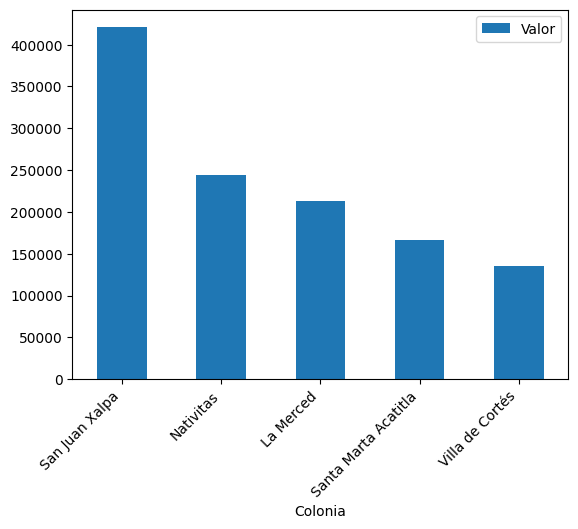

In [ ]:
PreciosPorColonia.head(5).plot (x= 'Colonia', kind='bar')

#El head es por que este DF tiene todas las colonias y solo queremos ver las 5 primeras.

plt.xticks(rotation=45, ha='right')


# 3. Calificación promedio de la tienda


In [72]:
Temporal_DF = { 'Tienda' : ['Tienda # 1','Tienda # 2', 'Tienda # 3','Tienda # 4'], 'Califiaciones en estrellas': [(tienda1 ['Calificación'].mean ()), (tienda2 ['Calificación'].mean ()), (tienda3 ['Calificación'].mean ()) , (tienda4 ['Calificación'].mean ())]}

Califiaciones = pd.DataFrame (Temporal_DF)
Califiaciones

,Tienda,Califiaciones en estrellas
0,Tienda # 1,3.976685
1,Tienda # 2,4.037304
2,Tienda # 3,4.048326
3,Tienda # 4,3.995759


# 4. Productos mas y menos vendidos


In [130]:
ModaProducto = [tienda['Producto'].value_counts().head(1).index [0] for tienda in Tiendas]
    ##El 0 del index es para que solo devuelva el nombre del producto, crudo, sin las especificaciones 
    # de la variable

ValorModa = [int (tienda['Producto'].value_counts().head(1).iloc[0]) for tienda in Tiendas]

    ##El iloc 0 es para que solo devuelva la cantidad del producto, crudo, sin las especificaciones 
    # de la variable

ProductImpopular = [tienda['Producto'].value_counts().tail(1).index [0] for tienda in Tiendas]
 
ValorImpopular = [int (tienda['Producto'].value_counts().tail(1).iloc[0]) for tienda in Tiendas]


Temporal_DF = {'Tiendas': ['Tienda # 1','Tienda # 2', 'Tienda # 3', 'Tienda # 4'],
               'Producto de mayor venta' : ModaProducto,
               'Cantidad de mayor venta' : ValorModa,
               'Producto de menor venta' : ProductImpopular,
               'Cantidad de menor venta' : ValorImpopular}

AgrupadoDeMayor = pd.DataFrame (Temporal_DF)
AgrupadoDeMayor



,Tiendas,Producto de mayor venta,Cantidad de mayor venta,Producto de menor venta,Cantidad de menor venta
0,Tienda # 1,Microondas,60,Celular ABXY,33
1,Tienda # 2,Iniciando en programación,65,Juego de mesa,32
2,Tienda # 3,Kit de bancas,57,Bloques de construcción,35
3,Tienda # 4,Cama box,62,Guitarra eléctrica,33


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Tienda # 1'),
  Text(1, 0, 'Tienda # 2'),
  Text(2, 0, 'Tienda # 3'),
  Text(3, 0, 'Tienda # 4')])

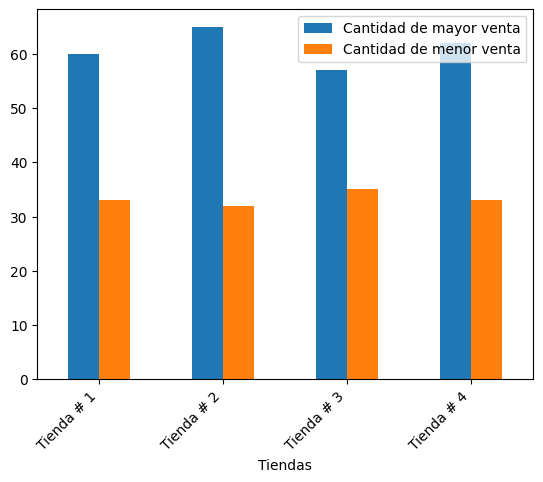

In [129]:
AgrupadoDeMayor.plot (x= 'Tiendas', kind='bar')
plt.xticks(rotation=45, ha='right')

# 5. Envío promedio por tienda

In [135]:
CostoEnvio =  [int (tienda ['Costo de envío'].mean ()) for tienda in Tiendas]

Temporal_DF = { 'Tienda' : ['Tienda # 1','Tienda # 2', 'Tienda # 3','Tienda # 4'], 
               'Costo promedio de envío': CostoEnvio}
DFEnvio = pd.DataFrame (Temporal_DF)
DFEnvio

,Tienda,Costo promedio de envío
0,Tienda # 1,26018
1,Tienda # 2,25216
2,Tienda # 3,24805
3,Tienda # 4,23459


# Graficación Y analisis final: 

Para comenzar me gustaría tener en cuenta el costo promedio de envio y las calificaciones de las tiendas, para ver  su incidencia en que tienda es más 
relevante 


In [ ]:


CostoEnvio = [int (tienda ['Costo de envío'].mean ()) for tienda in Tiendas]
EntradasPortienda = [int (tienda ['Precio'].mean ()) for tienda in Tiendas]
Calif = [tienda ['Calificación'].mean () for tienda in Tiendas]
    
Temporal_DF = { 'Tienda' : ['Tienda # 1','Tienda # 2', 'Tienda # 3','Tienda # 4'], 
               'Precio promedio de producto': EntradasPortienda,
               'Costo promedio de envío': CostoEnvio,
               'Total Con envio descontado': [EntradasPortienda[i] - CostoEnvio[i] for i in range(len(Tiendas))],
               'Calificación promedio': Calif
               }
    
DFEnvio = pd.DataFrame (Temporal_DF)
DFEnvio



,Tienda,Precio promedio de producto,Costo promedio de envío,Total Con envio descontado,Calificación promedio
0,Tienda # 1,487867,26018,461849,3.976685
1,Tienda # 2,473227,25216,448011,4.037304
2,Tienda # 3,465459,24805,440654,4.048326
3,Tienda # 4,440362,23459,416903,3.995759


Teniendo en cuenta que la calificación promedio de las tiendas varían al rededor de uan centesima, no me parecen relevantes; y teniendo en cuenta que el costo de envio varía por mucho unos 3000 pesos entre productos, y el tamaño de cada data frame es de 2359 filas, la diferencia potencial entre el envío más barato y más caro (tienda 1 y tienda 4) es de 3000*2359 = 7.077.000 pesos, lo cual es una cantidad inocua teniendo en cuenta que los ingresos totales pot tienda varían entre 1000 y 1200 millones de pesos, entonces no me parece relevante el costo de envio, ni la calificación, para determinar que tienda es más relevante.

Ahora, quisiera tener en cuenta, los productos más y menos vendidos de cada tienda, y la relación general con los otros productos de cada tienda

In [79]:
ModaProducto = [tienda['Producto'].value_counts().head(1).index [0] for tienda in Tiendas]
ValorModa = [int (tienda['Producto'].value_counts().head(1).iloc[0]) for tienda in Tiendas]
ProductImpopular = [tienda['Producto'].value_counts().tail(1).index [0] for tienda in Tiendas]
ValorImpopular = [int (tienda['Producto'].value_counts().tail(1).iloc[0]) for tienda in Tiendas]

Temporal_DF = {'Tiendas': ['Tienda # 1','Tienda # 2', 'Tienda # 3', 'Tienda # 4'],
               'Producto de mayor venta' : ModaProducto,
               'Cantidad de mayor venta' : ValorModa,
               'Producto de menor venta' : ProductImpopular,
               'Cantidad de menor venta' : ValorImpopular}

AgrupadoDeMayor = pd.DataFrame (Temporal_DF)
AgrupadoDeMayor



,Tiendas,Producto de mayor venta,Cantidad de mayor venta,Producto de menor venta,Cantidad de menor venta
0,Tienda # 1,Microondas,60,Celular ABXY,33
1,Tienda # 2,Iniciando en programación,65,Juego de mesa,32
2,Tienda # 3,Kit de bancas,57,Bloques de construcción,35
3,Tienda # 4,Cama box,62,Guitarra eléctrica,33


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Tienda # 1'),
  Text(1, 0, 'Tienda # 2'),
  Text(2, 0, 'Tienda # 3'),
  Text(3, 0, 'Tienda # 4')])

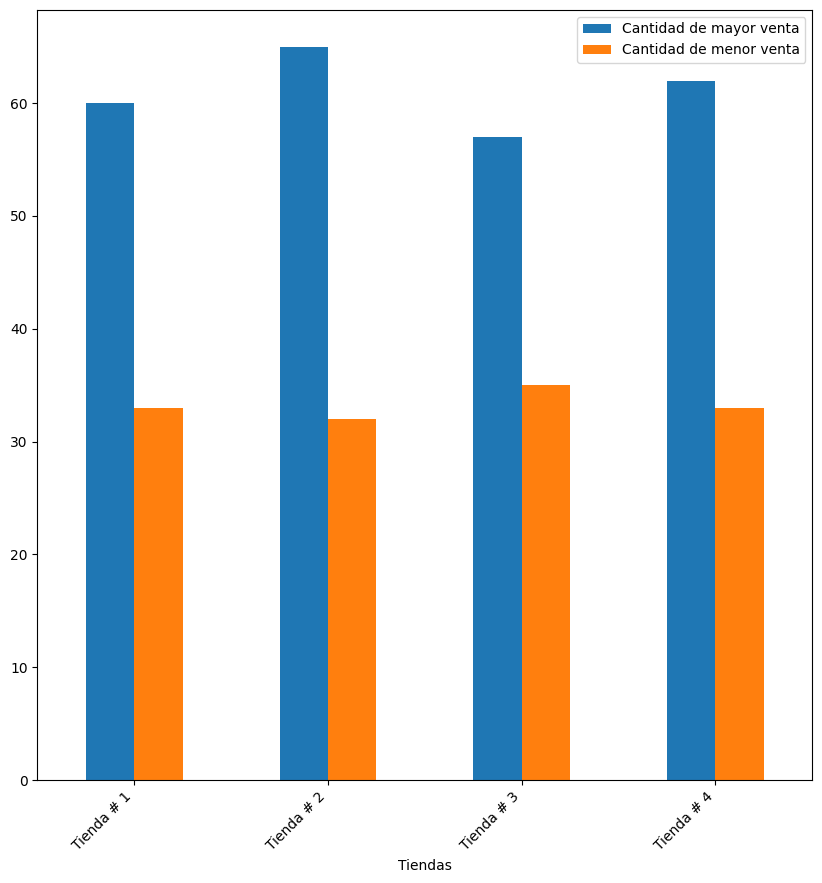

In [82]:
AgrupadoDeMayor.plot (x= 'Tiendas', kind='bar', figsize=(10, 10))
plt.xticks(rotation=45, ha='right')

La diferencia no fue demasiado significativa, ni diciente entre los tipos de productos ni sus ventas así que intenté ver el porcentaje de ventas por cada producto en todas las tiendas

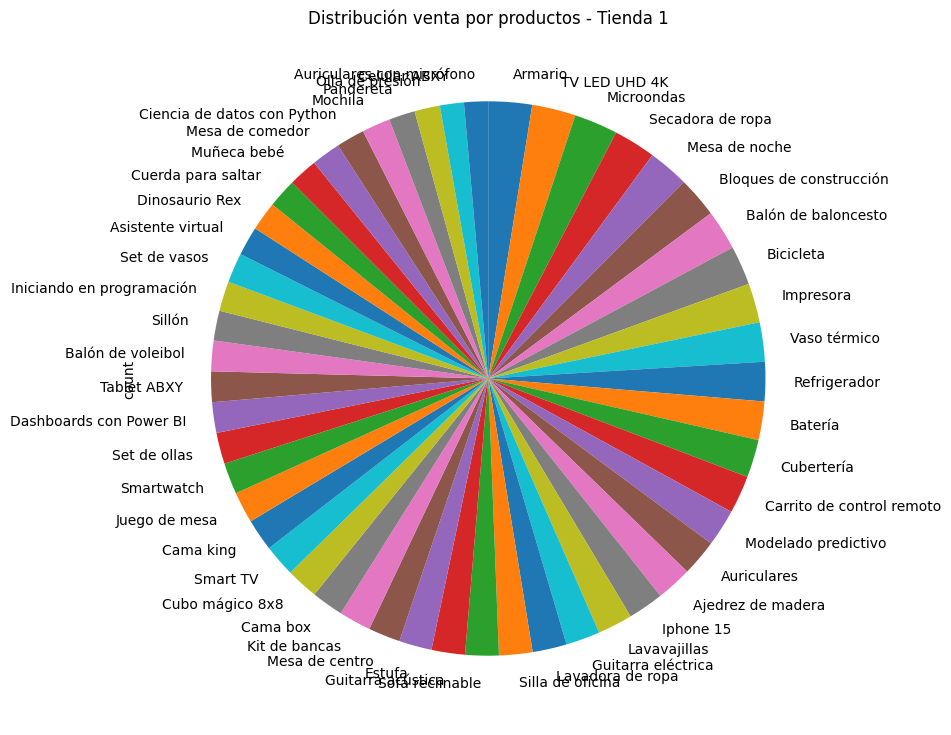

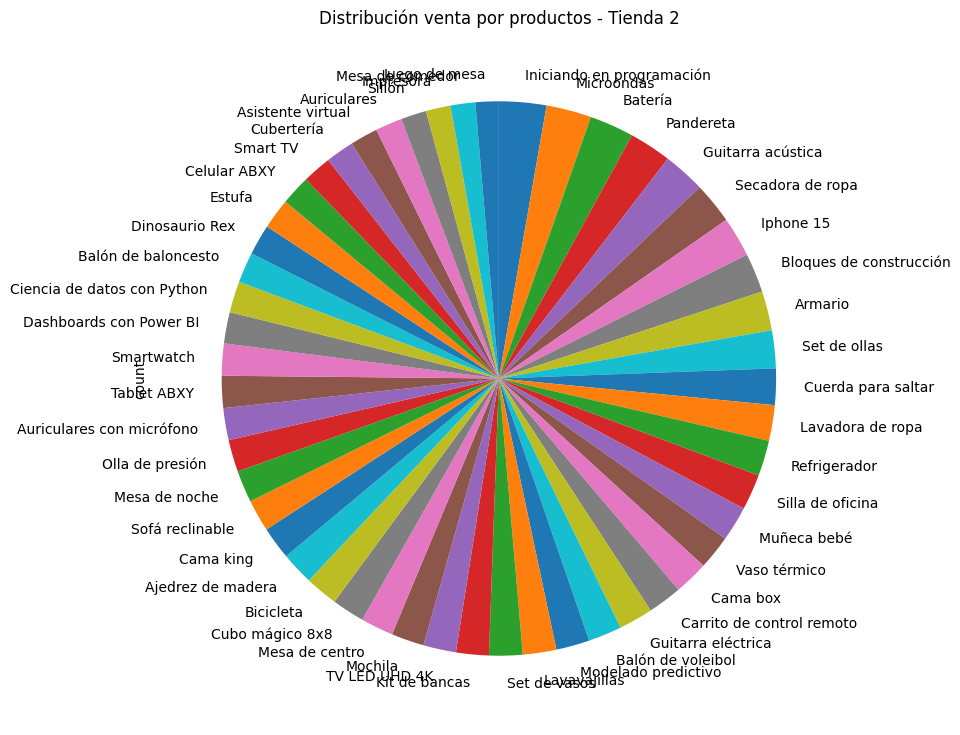

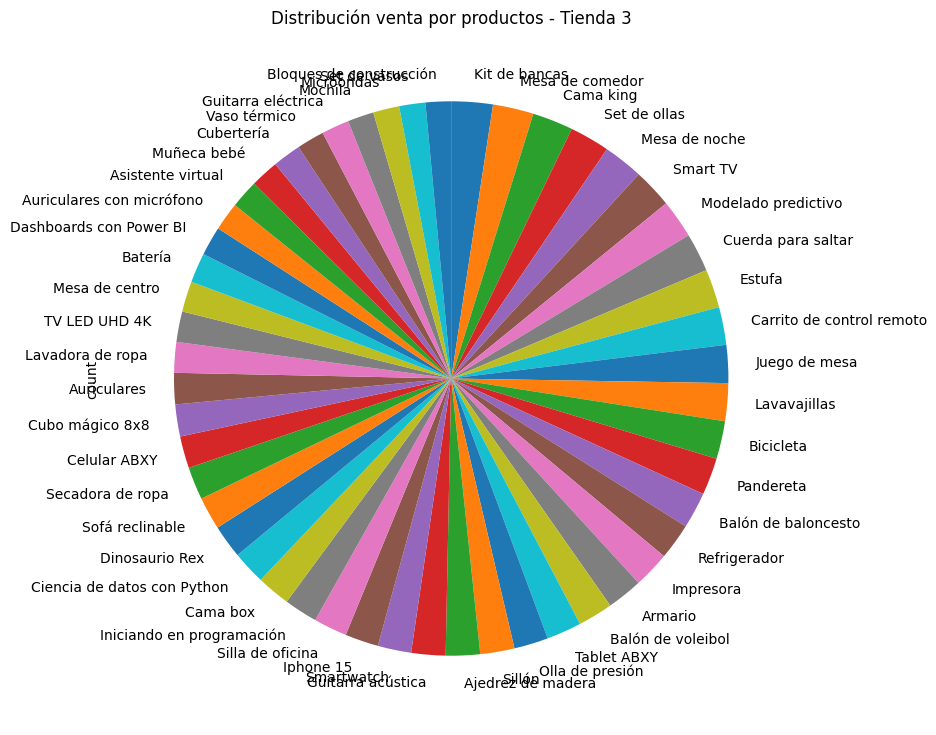

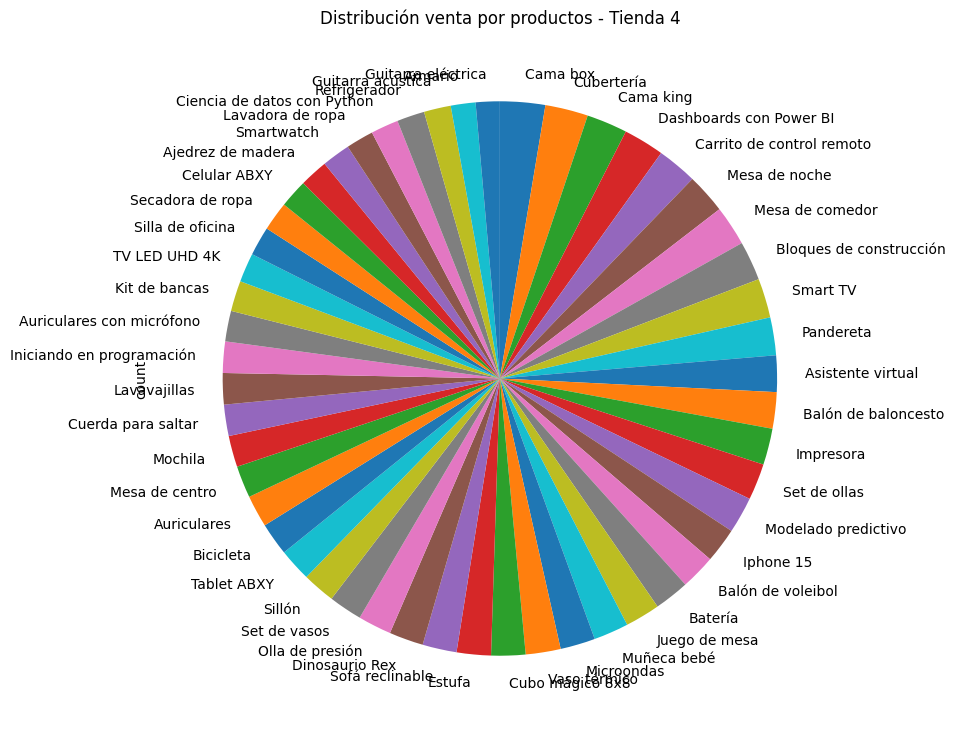

In [72]:
def Grafica_Torta (tienda,numero_tienda):
    DF_temp_prod = (tienda.groupby('Producto')['Producto'].value_counts()).reset_index().sort_values (by= 'count', ascending= False)
    df = pd.DataFrame (DF_temp_prod)
    
    df.plot.pie (y= 'count', labels = df ['Producto'], startangle=90, counterclock=False, legend = False,
             title = f"Distribución venta por productos - Tienda {numero_tienda}", figsize=(9, 9))

for numero_tienda, tienda in enumerate(Tiendas, 1):
    Grafica_Torta (tienda, numero_tienda)

Sin embargo, casi todos los productos tienen el mismo porcentaje de venta, de la mayoría de los productos está pareja de 1.7 a 2.3 %, nunca, tomando prioridad, una sobre otra en ninguna tienda. 

Ante esta falta de diferencia, la mejor manera de acentuar los resultados de cada una de las tiendas es ver si las ganancias están inclinadas hacia un mercado especifico: es decir, incluso si las ventas netas son parecidas entre productos, ¿Puede La manera en la que se inclina cada tienda por productos más o menos caros puede decirnos algo de su viabilidad?

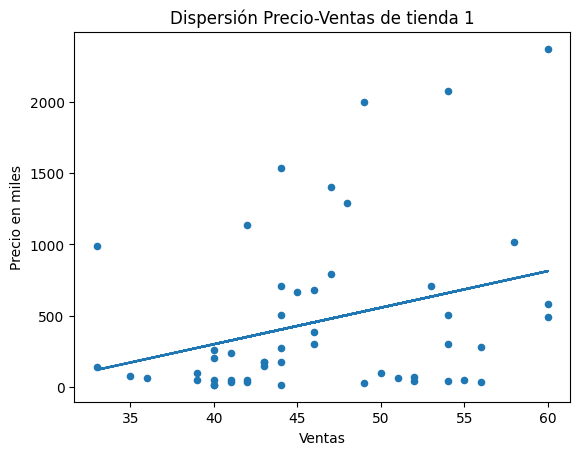

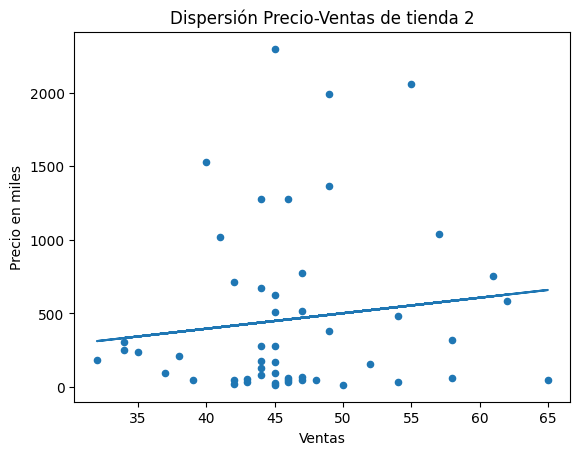

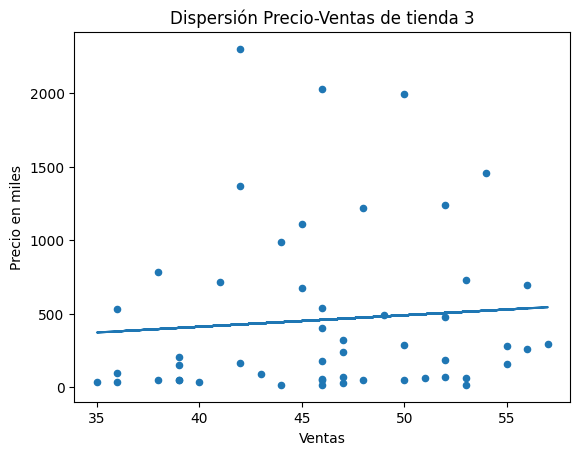

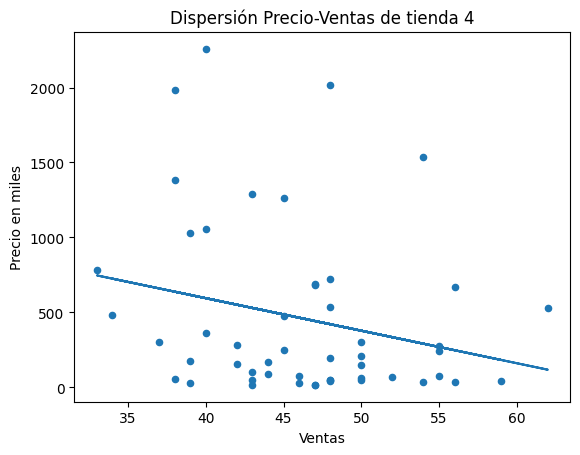

In [73]:
##Funcion para grafica
def GraficaDispercion (tienda, numero_tienda):
    DF_temp_Dinero = (tienda.groupby('Producto')['Precio'].mean()/1000).reset_index()
    DF_temp_Ventas = tienda.groupby('Producto') ['Producto'].value_counts().reset_index()
    
    df = DF_temp_Dinero.merge(DF_temp_Ventas, on='Producto')
    df.columns = ['Producto', 'Precio en miles', 'Ventas']
    df ['Entradas por producto En miles'] = df ['Precio en miles'] * df ['Ventas']
    
    #El reset index está ahi para que se haga un DF de los datos, particularmente para poder graficar despues si 
    # no, se vuelve una serie con indice etiquetado. que no tiene referencia para graficar o cruzar datos.

    df.plot.scatter(x='Ventas', y= 'Precio en miles', title = f"Dispersión Precio-Ventas de tienda {numero_tienda}")
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(x=df['Ventas'], y=df['Precio en miles'])
    plt.plot(df['Ventas'], slope*df['Ventas'] + intercept)
    return True
    
for numero_tienda, tienda in enumerate(Tiendas, 1):
    GraficaDispercion (tienda, numero_tienda)

Por primera vez vemos una variación de relevancia; si bien las ventas son parecidas, hay una clara tendencia en la primera tienda de depender de altas ventas de  productos de alto precio, mientras que es en las tiendas 2 y 3 es menor esta tendencia y es de plano inversa en la tienda numero 4.

Para poder visualizar la inestabilidad que estos datos revelan; un buen ejemplo es tomar los 3 productos que más dinero traen unitariamente, en cada tienda, y ver, su pocentaje representativo de las entradas de cada tienda, y como al descontarlos de estos, el orden de mayor a menor ingresos se ve afectado. 

In [76]:
lista_final = []

def Dataset_Resta   (tienda): 
    DF_temp_Dinero = (tienda.groupby('Producto')['Precio'].mean()).reset_index()
    DF_temp_Ventas = tienda.groupby('Producto') ['Producto'].value_counts().reset_index()
    
    df = DF_temp_Dinero.merge(DF_temp_Ventas, on='Producto')
    df.columns = ['Producto', 'Precio en miles', 'Ventas']
    df ['Entradas por producto En millones'] = df ['Precio en miles'] * df ['Ventas']/1000000

    df_ordenado= df.sort_values (by = 'Entradas por producto En millones', ascending= False)

    maximito = df_ordenado ['Entradas por producto En millones'].nlargest(3).sum () 
    lista_final.append (maximito)
    return lista_final

for tienda in Tiendas:
    Dataset_Resta (tienda)

EntradasPortienda_MILL = [ (tienda ['Precio'].sum ()/1000000) for tienda in Tiendas]

Temporal_DF = { 'Tienda' : ['Tienda # 1','Tienda # 2', 'Tienda # 3','Tienda # 4'], 
               
               'Ingresos Crudos (Millones)': EntradasPortienda_MILL,
               'Ingresos del podio (Millones)': lista_final,   
               'Ingresos sin top (Millones)': [EntradasPortienda_MILL[i] - lista_final[i] for i in range(len(Tiendas))],
               'Porcenaje en el top': [lista_final[i] / EntradasPortienda_MILL[i] * 100 for i in range(len(Tiendas))],
                }

DFPLATA_ORDEN = pd.DataFrame (Temporal_DF)
DFPLATA_ORDEN


,Tienda,Ingresos Crudos (Millones),Ingresos del podio (Millones),Ingresos sin top (Millones),Porcenaje en el top
0,Tienda # 1,1150.8804,352.1957,798.6847,30.602285
1,Tienda # 2,1116.3435,314.2333,802.1102,28.148442
2,Tienda # 3,1098.0196,289.7845,808.2351,26.391560
3,Tienda # 4,1038.3757,269.7832,768.5925,25.981271


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Tienda # 1'),
  Text(1, 0, 'Tienda # 2'),
  Text(2, 0, 'Tienda # 3'),
  Text(3, 0, 'Tienda # 4')])

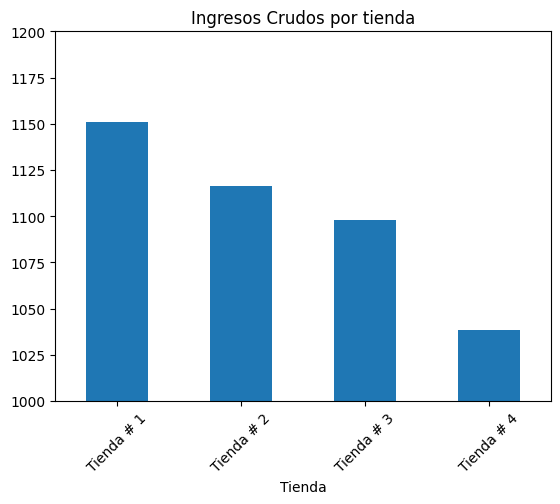

In [77]:
DFPLATA_ORDEN = DFPLATA_ORDEN.sort_values (by= 'Ingresos Crudos (Millones)', ascending= False)

DFPLATA_ORDEN.plot (x= 'Tienda', y= 'Ingresos Crudos (Millones)', kind='bar', legend=False,  title= 'Ingresos Crudos por tienda')
plt.ylim(1000, 1200)
plt.xticks(rotation=45)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Tienda # 3'),
  Text(1, 0, 'Tienda # 2'),
  Text(2, 0, 'Tienda # 1'),
  Text(3, 0, 'Tienda # 4')])

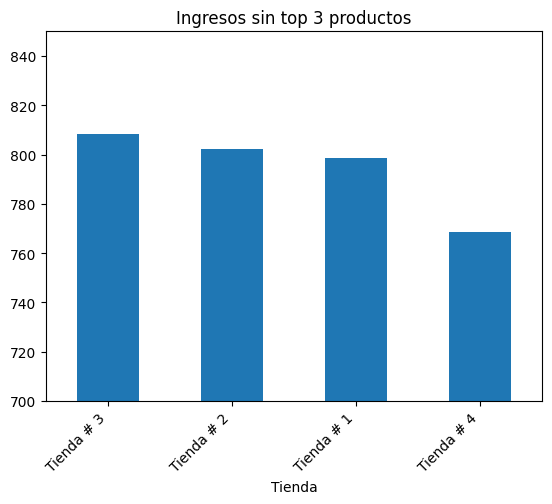

In [78]:
DFPLATA_ORDEN = DFPLATA_ORDEN.sort_values (by= 'Ingresos sin top (Millones)', ascending= False)

DFPLATA_ORDEN.plot (x= 'Tienda', y= 'Ingresos sin top (Millones)', kind='bar', legend=False, title= 'Ingresos sin top 3 productos')
plt.ylim(700, 850)
plt.xticks(rotation=45, ha='right')

# Informe Final

### Sobre las calificaciones y envios

Como dije arriba, las calificaciones y envios me parecen demasiado parecidos para ser relevantes, en especial teniendo en cuenta para los envios como ya he mencionado, estamos lidiando en presupuestos de cientos de millones, y una diferencia de menos de una decena de millones, no es relevante para esta discusión. 

### Sobre los productos más y menos vendidos

Entre ellos encontramos cierta variedad, pero en un rango muy limitado, las cantidades y sus barras son muy limitados, tanto que la categoría más comun entre todas las tiendas son la misma; los muebles, la mayor relevancia para mi de este punto vendrá en el siguiente punto para hablar de la dispersión de ingresos. 

### Sobre los productos más y menos vendidos. 

Este es mi punto más diciente, pues todos los anteriores mostraban a las tiendas muy parecidas, incluso, cuando vemos la dispersión de ventas de cada producto, es muy par en todas las tiendas. Sin embargo, cuando vemos los graficos de dispersión, entre costo promedio y cantidad de venta, vemos que hay una diferencia entre tiendas la estrategia, en especial: las tiendas 1 y 4. 

La tienda 1 tiende a una venta muy arriesgada, que ha favorecido sus ganancias netas en su base de datos, y la tienda 4 ha vendido principalmente productos de bajo precio pero estabilizando su venta. Las tiendas 2 y 3, son el punto medio en estos respectos, pues como vemos en sus graficos de dispersión tieden a un balance (sin contar que sus puntuaciones de satisfaccion del cliente son las más altas), además de que en todo respecto del que voy a hablar de la 1 o 4 no destacan para bien ni para mal. 

Lo que más me llama la atención de la tienda 1, como dije es su inestabilidad, en la última parte de los gráficos con el ejercicio, se ve que sin los productos más caros pierde más de un 30% de su venta total, siendo que es la tienda con mayor venta, ese porcentaje juega en su contra, además de que es la segunda tienda con menor participación de la categoría de producto más popular. 

Por el lado de la tienda 4, incluso si es más estable sus numeros más bajos son inevitables, en el ejercicio de quitar el top 3 de ventas, nominalmente y porcentualmente fue el que menos perdió pero es por que sigue siendo la que menos generó crudamente, y volviendo al costo de los envios, la diferencia de costo de envio no va a complementar esas perdidas.

## Pensamientos finales

Todas las tiendas son tremendamente parecidas en su desempeño, para poder hablar de ellas debo especificar sobre lo más detallado posible, y si bien creo que nominalmente la tienda 4 se ha desempeñado peor: es la tienda 1, es un mayor riesgo, sus ganancias son mayores, pero si algo nos han enseñado las constantes burbujas en los sectores financieros, y de tecnología, es que la pluralización de cualquier cartera de activos es valiosa, y en este caso, evitar el riesgo, implica:

    1. Apuntar a las tiendas con menores riesgos, con productos menos costosos, entre ellos menos costos de garantias.
    2. Consolidar especificidad del mercado: ir sobre seguro a las categorías que ya les compra el publico (Muebles).
    3. No asumir que la ganancia efimera es significativa de la salud a largo plazo del negocio.